# 01 — Data Exploration

Explore the underlying data for **Stocktaking AI** before running the pipeline:

1. Project configuration (`configs/config.yaml`)
2. Reference image gallery (`data/gallery/`)
3. Product metadata (`data/metadata/`)
4. COCO benchmark set (`data/benchmark/`)
5. Query images (`data/query/`)

This notebook is **read-only** and does not execute any AI models (it does not load RF-DETR, SAM2, or SigLIP2), so it can be run on a machine without a GPU.

## 1. Environment Setup

In [151]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "configs" / "config.yaml").is_file(), (
    "configs/config.yaml not found — check the notebook working directory."
)

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [152]:
import json
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.core.config import load_config

pd.set_option("display.max_colwidth", 80)
%matplotlib inline

## 2. Project Configuration

Load `AppConfig` via the single entry point `load_config()` (do not read YAML directly—per project rules).

In [153]:
config = load_config()

print(f"App:          {config.app.name} v{config.app.version} ({config.app.environment})")
print(f"Device:       {config.app.device}")
print(f"Detection:    backend={config.detection.backend}")
print(f"Refinement:   backend={config.refinement.backend}, enabled={config.refinement.enabled}")
print(f"Retrieval:    backend={config.retrieval.backend}, top_k={config.retrieval.top_k}")
print(f"Plugins:      ocr={config.plugins.ocr.enabled}, color={config.plugins.color.enabled}, barcode={config.plugins.barcode.enabled}")

App:          Stocktaking AI v0.1.0 (development)
Device:       cuda
Detection:    backend=rf_detr
Refinement:   backend=sam2, enabled=True
Retrieval:    backend=siglip2, top_k=5
Plugins:      ocr=True, color=True, barcode=True


In [154]:
# Key data paths; resolve absolutely via config.resolve_path()
paths = {
    "gallery_dir": config.paths.gallery_dir,
    "metadata_dir": config.paths.metadata_dir,
    "benchmark_dir": config.paths.benchmark_dir,
    "benchmark_images_dir": config.paths.benchmark_images_dir,
    "benchmark_labels_dir": config.paths.benchmark_labels_dir,
    "query_dir": config.paths.query_dir,
    "cache_dir": config.paths.cache_dir,
    "output_dir": config.paths.output_dir,
}

for name, rel_path in paths.items():
    abs_path = config.resolve_path(rel_path)
    exists = "OK" if abs_path.exists() else "MISSING"
    print(f"[{exists:7}] {name:22} -> {abs_path}")

[OK     ] gallery_dir            -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\gallery
[OK     ] metadata_dir           -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\metadata
[OK     ] benchmark_dir          -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark
[OK     ] benchmark_images_dir   -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark\images
[OK     ] benchmark_labels_dir   -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark\_annotations.coco.json
[OK     ] query_dir              -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\query
[OK     ] cache_dir              -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache
[MISSING] output_dir             -> G:\VsCode\Python\DACN\stocktaking_ai_mini\data\outputs


## 3. Gallery — reference images by SKU

`data/gallery/` contains subdirectories, each corresponding to an SKU (the directory name maps to `catalog.id_mapping` in the configuration).

In [155]:
gallery_dir = config.resolve_path(config.paths.gallery_dir)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

sku_dirs = sorted([d for d in gallery_dir.iterdir() if d.is_dir()]) if gallery_dir.exists() else []

gallery_counts = {}
for sku_dir in sku_dirs:
    images = [f for f in sku_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
    gallery_counts[sku_dir.name] = len(images)

gallery_df = pd.DataFrame(
    [{"sku_folder": k, "num_images": v} for k, v in gallery_counts.items()]
).sort_values("num_images", ascending=False).reset_index(drop=True)

print(f"Total number of SKU folders: {len(gallery_df)}")
print(f"Total number of gallery images: {gallery_df['num_images'].sum()}")
gallery_df

Total number of SKU folders: 21
Total number of gallery images: 281


,sku_folder,num_images
0,インテグレート フォルミングチークス（OR210）,27
1,インテグレート アイブローペンシル（BR641）,23
2,7000000002,23
3,マジョリカマジョルカ シャドーカスタマイズ（PK300）,21
4,マジョリカマジョルカ シャドーカスタマイズ（BE203）,21
5,外箱ABC,21
6,外箱ABA,19
7,7000000000,17
8,8000000016,16
9,アネッサ パーフェクトUV スキンケアスプレー,14


In [156]:

metadata_dir = config.resolve_path(config.paths.metadata_dir)
def load_json_safe(path):
    if not path.is_file():
        print(f"[MISSING] {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

products = load_json_safe(metadata_dir / config.catalog.products_filename)

folder_to_product_name = {}
product_id_to_name = {}

if isinstance(products, list):
    for product in products:
        product_id = str(product.get("product_id", ""))
        product_name = product.get("product_name") or product_id
        folder_name = product.get("folder")
        if product_id:
            product_id_to_name[product_id] = product_name
        if folder_name:
            folder_to_product_name[folder_name] = product_name

def display_product_name(raw_name):
    if raw_name is None:
        return ""
    
    raw_str = str(raw_name)
    name = folder_to_product_name.get(
        raw_str, 
        product_id_to_name.get(raw_str, raw_str)
    )
    
    # Ép kiểu string và thay thế triệt để các ký tự NGOẶC NHẬT / FULLWIDTH
    return (
        str(name)
        .replace("（", "(")
        .replace("）", ")")
        .replace("［", "[")
        .replace("］", "]")
    )

In [157]:
# Match the gallery folder name with catalog.id_mapping in the config
id_mapping = config.catalog.id_mapping  # {"1": "アネッサ...", ...}
mapped_names = set(id_mapping.values())
gallery_names = set(gallery_counts.keys())

only_in_gallery = sorted(gallery_names - mapped_names)
only_in_config = sorted(mapped_names - gallery_names)

print(f"SKUs in id_mapping:       {len(mapped_names)}")
print(f"SKUs in data/gallery/:    {len(gallery_names)}")
print(f"Only in gallery (missing mapping in config): {only_in_gallery}")
print(f"Only in config (missing gallery images):      {only_in_config}")

SKUs in id_mapping:       18
SKUs in data/gallery/:    21
Only in gallery (missing mapping in config): ['CASCAN', 'DAY_BODY', 'GOMMAGE', 'KEM_TAY_DA', 'Sun_Fresh', 'VITAMIN', 'ZEESEA', 'ZIAJA', 'アネッサ\u3000パーフェクトUV\u3000スキンケアスプレー', 'インテグレート\u3000アイブローペンシル（BR641）', 'インテグレート\u3000フォルミングチークス（OR210）', 'マキアージュ\u3000スポンジパフ', 'マジョリカマジョルカ\u3000シャドーカスタマイズ（BE203）', 'マジョリカマジョルカ\u3000シャドーカスタマイズ（PK300）']
Only in config (missing gallery images):      ['7000000001', '7000000005', '7000000009', '7000000011', '7000000014', 'アネッサ パーフェクトUV スキンケアスプレー', 'インテグレート アイブローペンシル（BR641）', 'インテグレート フォルミングチークス（OR210）', 'マキアージュ スポンジパフ', 'マジョリカマジョルカ シャドーカスタマイズ（BE203）', 'マジョリカマジョルカ シャドーカスタマイズ（PK300）']


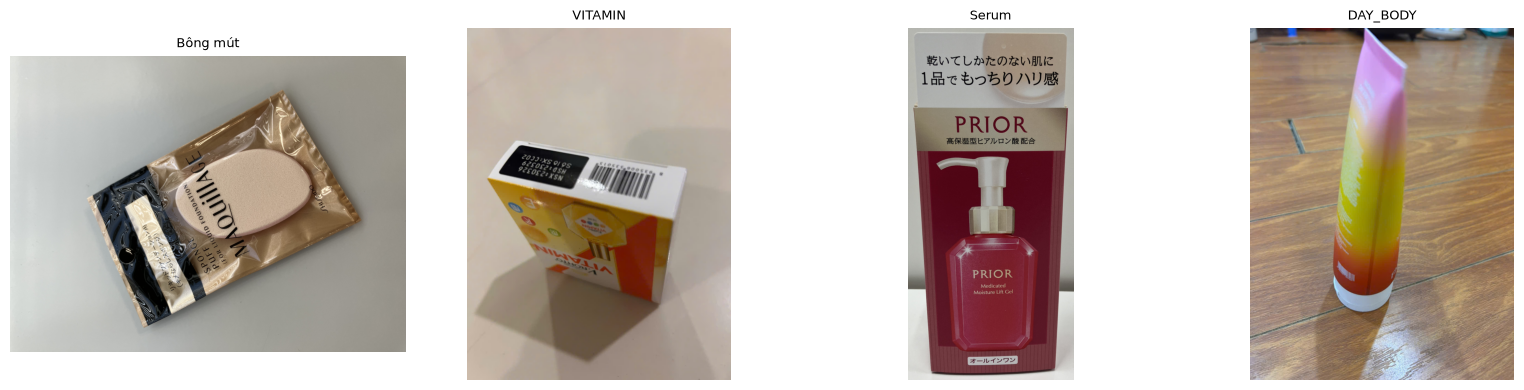

In [158]:
# Check out some sample photos from a few random SKUs
sample_skus = random.sample(sku_dirs, k=min(4, len(sku_dirs))) if sku_dirs else []

if sample_skus:
    fig, axes = plt.subplots(1, len(sample_skus), figsize=(4 * len(sample_skus), 4))
    axes = [axes] if len(sample_skus) == 1 else axes
    for ax, sku_dir in zip(axes, sample_skus):
        images = [f for f in sku_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
        if images:
            img = Image.open(images[0])
            ax.imshow(img)
        ax.set_title(display_product_name(sku_dir.name), fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No SKUs available to display.")

## 4. Product metadata

- `products.json` — product catalog compiled by `MetadataBuilder` (based on `catalog.id_mapping` + `data/gallery/`)
- `product_ids.json` — internal ID mapping
- `product_colors.json` — reference color standards (RGB/hex) used for the Color + Reranker plugin

In [159]:

products = load_json_safe(metadata_dir / config.catalog.products_filename)
product_ids = load_json_safe(metadata_dir / config.catalog.product_ids_filename)
product_colors = load_json_safe(metadata_dir / "product_colors.json")

In [160]:
if products is not None:
    print(f"products.json: {type(products).__name__}, "
          f"{len(products)} entries")
    # Print a few initial entries to inspect the actual schema
    preview = products[:3] if isinstance(products, list) else dict(list(products.items())[:3])
    print(json.dumps(preview, ensure_ascii=False, indent=2)[:1500])

products.json: list, 22 entries
[
  {
    "product_id": "1",
    "product_name": "Kem chống nắng",
    "brand": "",
    "category": "",
    "barcode": "4909978147853",
    "description": "",
    "folder": "アネッサ　パーフェクトUV　スキンケアスプレー",
    "image_count": 14
  },
  {
    "product_id": "2",
    "product_name": "Kẻ mắt（BR641）",
    "brand": "",
    "category": "",
    "barcode": "",
    "description": "",
    "folder": "インテグレート　アイブローペンシル（BR641）",
    "image_count": 23
  },
  {
    "product_id": "3",
    "product_name": "Phấn má（OR210）",
    "brand": "",
    "category": "",
    "barcode": "4901872273652",
    "description": "",
    "folder": "インテグレート　フォルミングチークス（OR210）",
    "image_count": 27
  }
]


,product_id,name,rgb,hex
0,PK300,PK300,"[109, 63, 62]",#6D3F3E
1,BE203,BE203,"[199, 161, 148]",#C7A194
2,RD500,RD500,"[190, 55, 65]",#BE3741
3,BR784,BR784,"[125, 75, 60]",#7D4B3C
4,OR300,OR300,"[220, 105, 55]",#DC6937
5,YE300,YE300,"[220, 185, 65]",#DCB941
6,GR300,GR300,"[85, 125, 85]",#557D55
7,BL300,BL300,"[65, 90, 145]",#415A91
8,PU300,PU300,"[130, 80, 145]",#825091
9,PK301,PK301,"[225, 135, 155]",#E1879B


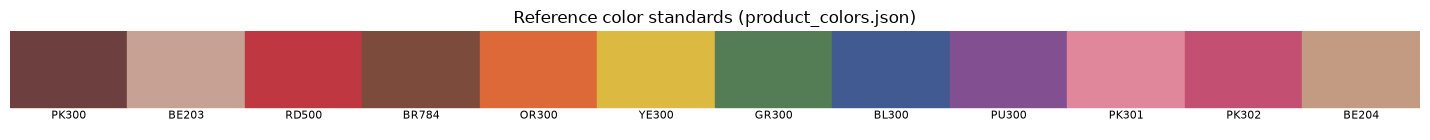

In [161]:
if product_colors is not None:
    color_df = pd.DataFrame([
        {"product_id": k, "name": v.get("name"), "rgb": v.get("rgb"), "hex": v.get("hex")}
        for k, v in product_colors.items()
    ])
    display(color_df)

    # Visualize each reference color swatch
    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(color_df)), 1.5))
    for i, row in color_df.iterrows():
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=row["hex"]))
        ax.text(i + 0.5, -0.15, row["product_id"], ha="center", fontsize=8)
    ax.set_xlim(0, len(color_df))
    ax.set_ylim(-0.3, 1)
    ax.axis("off")
    ax.set_title("Reference color standards (product_colors.json)")
    plt.tight_layout()
    plt.show()

## 5. Benchmark — COCO Evaluation Dataset

`data/benchmark/_annotations.coco.json` chứa `images`, `annotations`, `categories`. `category_id` ánh xạ trực tiếp tới `product_id` nội bộ (theo README, mục 7).

In [162]:
benchmark_labels_path = config.resolve_path(config.paths.benchmark_labels_dir)
coco = load_json_safe(benchmark_labels_path)

if coco is not None:
    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    categories = coco.get("categories", [])

    print(f"Number of images:        {len(images)}")
    print(f"Number of annotations (bboxes):   {len(annotations)}")
    print(f"Number of categories (SKUs/classes):  {len(categories)}")

Number of images:        31
Number of annotations (bboxes):   293
Number of categories (SKUs/classes):  9


In [163]:
if coco is not None:
    categories_df = pd.DataFrame(categories)
    display(categories_df)

,id,name,supercategory
0,0,train1,none
1,1,1,train1
2,2,2,train1
3,3,3,train1
4,4,4,train1
5,5,5,train1
6,6,6,train1
7,7,7,train1
8,8,8,train1


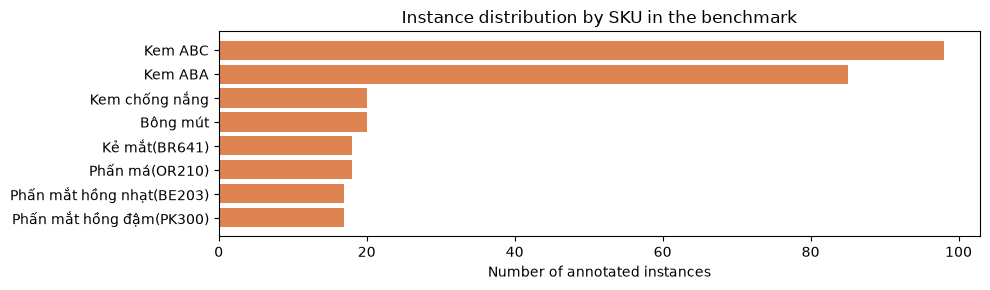

In [164]:
if coco is not None:
    cat_id_to_name = {
        c["id"]: display_product_name(c.get("name", str(c["id"]))) 
        for c in categories
    }

    ann_counts = Counter(a["category_id"] for a in annotations)

    dist_df = pd.DataFrame(
        [{"category_id": cid, "name": cat_id_to_name.get(cid, "?"), "num_instances": n}
         for cid, n in ann_counts.items()]
    ).sort_values("num_instances", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(dist_df))))
    ax.barh(dist_df["name"], dist_df["num_instances"], color="#DD8452")
    ax.set_xlabel("Number of annotated instances")
    ax.set_title("Instance distribution by SKU in the benchmark")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

count    31.000000
mean      9.451613
std       2.501183
min       6.000000
25%       7.000000
50%       9.000000
75%      12.000000
max      13.000000
Name: instances_per_image, dtype: float64


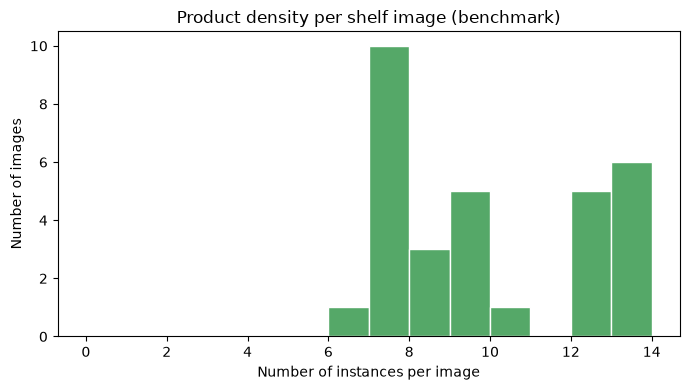

In [165]:
if coco is not None and images:
    ann_per_image = Counter(a["image_id"] for a in annotations)
    density = pd.Series([ann_per_image.get(img["id"], 0) for img in images], name="instances_per_image")

    print(density.describe())
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(density, bins=range(0, density.max() + 2), color="#55A868", edgecolor="white")
    ax.set_xlabel("Number of instances per image")
    ax.set_ylabel("Number of images")
    ax.set_title("Product density per shelf image (benchmark)")
    plt.tight_layout()
    plt.show()

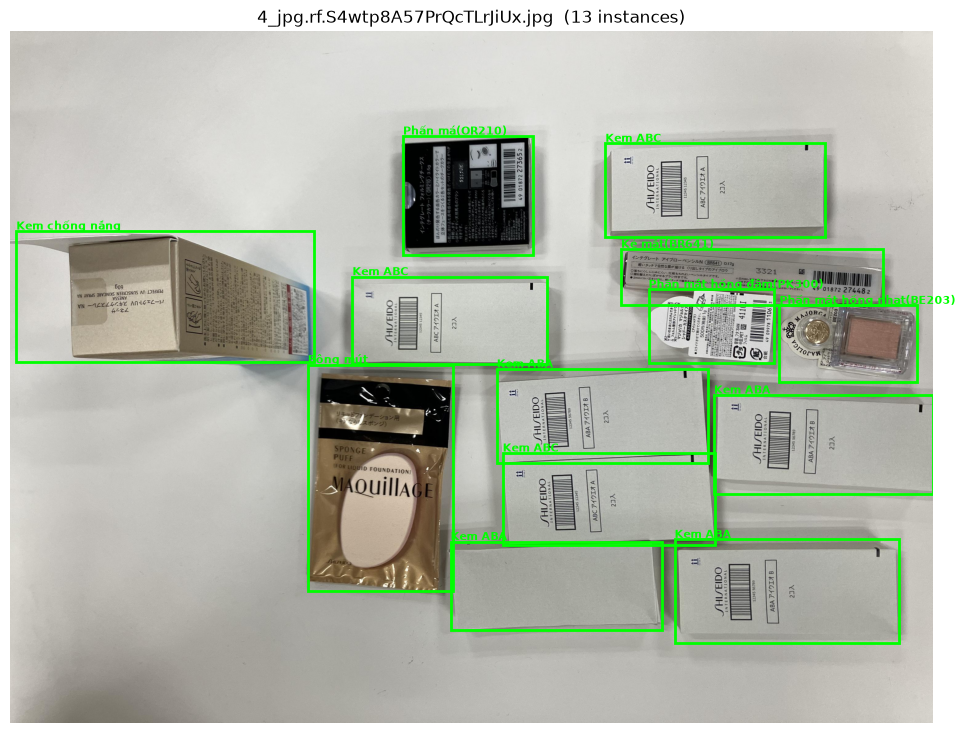

In [166]:
# Visualize ground-truth bounding boxes on a sample benchmark image
import matplotlib.patches as patches

benchmark_images_dir = config.resolve_path(config.paths.benchmark_images_dir)

if coco is not None and images:
    cat_id_to_name = {
        c["id"]: display_product_name(c.get("name", str(c["id"]))) 
        for c in categories
    }
    
    sample_image_meta = random.choice(images)
    image_path = benchmark_images_dir / sample_image_meta["file_name"]

    image_annotations = [a for a in annotations if a["image_id"] == sample_image_meta["id"]]

    if image_path.is_file():
        img = Image.open(image_path)
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(img)
        for ann in image_annotations:
            x, y, w, h = ann["bbox"]  # COCO format: [x, y, width, height]
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            label_text = cat_id_to_name.get(ann["category_id"], "?")
            ax.text(x, max(0, y - 5), label_text, color="lime", fontsize=8, weight="bold")
            
        ax.set_title(f"{sample_image_meta['file_name']}  ({len(image_annotations)} instances)")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"[MISSING] Benchmark image file not found: {image_path}")

## 6. Query Images (`data/query/`)

Real shelf images will be passed to `InventoryPipeline.run()` during inference (see notebook `07_end_to_end_pipeline`).

In [167]:
query_dir = config.resolve_path(config.paths.query_dir)
query_images = sorted([f for f in query_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]) if query_dir.exists() else []

print(f"Number of images in data/query/: {len(query_images)}")
for f in query_images[:10]:
    print(" -", f.name)

Number of images in data/query/: 10
 - 1.jpg
 - 10.jpg
 - 11.jpg
 - 12.jpg
 - 3.jpg
 - 4.jpg
 - 5.jpg
 - 6.jpg
 - 7.jpg
 - 9.jpg


## 7. Summary

In [168]:
summary = {
    "SKUs in gallery": len(gallery_df) if not gallery_df.empty else 0,
    "Total gallery images": int(gallery_df["num_images"].sum()) if not gallery_df.empty else 0,
    "SKUs in catalog.id_mapping": len(id_mapping),
    "Benchmark images": len(coco.get("images", [])) if coco else 0,
    "Benchmark annotations": len(coco.get("annotations", [])) if coco else 0,
    "Benchmark categories": len(coco.get("categories", [])) if coco else 0,
    "Query images": len(query_images),
}

pd.DataFrame([summary]).T.rename(columns={0: "Count"})

,Count
SKUs in gallery,21
Total gallery images,281
SKUs in catalog.id_mapping,18
Benchmark images,31
Benchmark annotations,293
Benchmark categories,9
Query images,10


---
**Quick observations (fill in manually after running on the actual data):**

- Which SKU has the fewest gallery images → does this create a retrieval risk for that SKU?
- Are there any mismatches between `catalog.id_mapping` and the actual gallery folders?
- Is the benchmark severely class-imbalanced (affecting F1 evaluation)?
- What is the average product density per image → does it affect the overlap threshold (`refinement.trigger`)?

**Next notebook:** `02_detection_analysis.ipynb` — run the detector and analyze predicted bounding boxes against the ground truth here.
